<a href="https://colab.research.google.com/github/AnnaZapototska/goit-colab-homeworks/blob/development/hw_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import timeit

# 4𝑥21+5𝑥22−2𝑥1𝑥2+3𝑥1−6𝑥2

np.random.seed(42)
x1 = np.random.rand(100)
x2 = np.random.rand(100)

def polynomial(x1, x2):
    return 4 * x1**2 + 5 * x2**2 - 2 * x1 * x2 + 3 * x1 - 6 * x2

y = polynomial(x1, x2)

data = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})
data.head()

,x1,x2,y
0,0.374540,0.031429,1.477562
1,0.950714,0.636410,3.464113
2,0.731994,0.314356,2.486992
3,0.598658,0.508571,0.862420
4,0.156019,0.907566,-1.044786


In [201]:
poly = PolynomialFeatures(degree=2, include_bias=True)

# Generate the additional features
X_poly = poly.fit_transform(data[['x1', 'x2']])

poly_data = pd.DataFrame(
    X_poly,
    columns=poly.get_feature_names_out()
)

poly_data['y'] = data['y']

poly_data.head()

,1,x1,x2,x1^2,x1 x2,x2^2,y
0,1.0,0.374540,0.031429,0.140280,0.011771,0.000988,1.477562
1,1.0,0.950714,0.636410,0.903858,0.605044,0.405018,3.464113
2,1.0,0.731994,0.314356,0.535815,0.230107,0.098820,2.486992
3,1.0,0.598658,0.508571,0.358392,0.304460,0.258644,0.862420
4,1.0,0.156019,0.907566,0.024342,0.141597,0.823677,-1.044786


Part 3 of the main task:

In [202]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.c_[np.ones(len(X_train)), X_train]
X_test = np.c_[np.ones(len(X_test)), X_test]

In [203]:
def polynomial_regression_gradient_descent(X, y, lr=0.01, n_iter=1000):
    m = len(y)
    losses = []
    theta = np.zeros(X.shape[1])

    prev_loss = np.inf
    tol = 1e-4

    for epoch in range(n_iter):
        y_pred = X @ theta
        errors = y_pred - y
        loss = np.mean(errors ** 2)

        if abs(prev_loss - loss) < tol:
          break
        losses.append(loss)
        prev_loss = loss

        gradient = (2 / m) * X.T @ errors
        theta -= lr * gradient

    return theta, losses, len(losses)

In [204]:
def polynomial_regression_SGD(X, y, lr=0.01, n_iter=1000):
    m, n = X.shape
    theta = np.zeros(n)
    losses = []
    prev_loss = np.inf
    tol = 1e-4

    for epoch in range(n_iter):
        indices = np.random.permutation(m)
        for idx in indices:
            xi = X[idx:idx+1]
            yi = y[idx]
            grad = xi.T @ (xi @ theta - yi)
            theta -= lr * grad
        y_pred = X @ theta
        loss = np.mean((y_pred - y) ** 2)

        if abs(prev_loss - loss) < tol:
          break
        losses.append(loss)
        prev_loss = loss

    return theta, losses, len(losses)


In [205]:
def polynomial_regression_rmsprop(X, y, lr=0.01, n_iter=1000, decay=0.9, eps=1e-8):

    m, n = X.shape
    theta = np.zeros(n)
    cache = np.zeros(n)
    losses = []
    prev_loss = np.inf
    tol = 1e-4

    for epoch in range(n_iter):
        indices = np.random.permutation(m)
        for idx in indices:
            xi = X[idx:idx+1]
            yi = y[idx]
            grad = xi.T @ (xi @ theta - yi)
            cache = decay * cache + (1 - decay) * grad**2
            theta -= lr * grad / (np.sqrt(cache) + eps)
        y_pred = X @ theta
        loss = np.mean((y_pred - y) ** 2)

        if abs(prev_loss - loss) < tol:
          break
        losses.append(loss)
        prev_loss = loss

    return theta, losses, len(losses)


In [206]:
def polynomial_regression_adam(X, y, lr=0.01, n_iter=1000, beta1=0.9, beta2=0.999, eps=1e-8):

    m, n = X.shape
    theta = np.zeros(n)
    m_t = np.zeros(n)
    v_t = np.zeros(n)

    losses = []
    t = 0

    prev_loss = np.inf
    tol = 1e-4

    for epoch in range(n_iter):
        indices = np.random.permutation(m)
        for idx in indices:
            t += 1
            xi = X[idx:idx+1]
            yi = y[idx]
            grad = xi.T @ (xi @ theta - yi)
            m_t = beta1 * m_t + (1-beta1) * grad
            v_t = beta2 * v_t + (1-beta2) * grad**2
            m_hat = m_t / (1-beta1**t)
            v_hat = v_t / (1-beta2**t)
            theta -= lr * m_hat / (np.sqrt(v_hat)+eps)
        y_pred = X @ theta
        loss = np.mean((y_pred - y) ** 2)

        if abs(prev_loss - loss) < tol:
          break
        losses.append(loss)
        prev_loss = loss
    return theta, losses, len(losses)

In [207]:
def polynomial_regression_nadam(X, y, lr=0.01, n_iter=1000, beta1=0.9, beta2=0.999, eps=1e-8):

    m, n = X.shape
    theta = np.zeros(n)
    m_t = np.zeros(n)
    v_t = np.zeros(n)
    losses = []
    t = 0

    prev_loss = np.inf
    tol = 1e-4

    for epoch in range(n_iter):
        indices = np.random.permutation(m)
        for idx in indices:
            t += 1
            xi = X[idx:idx+1]
            yi = y[idx]
            grad = xi.T @ (xi @ theta - yi)
            m_t = beta1 * m_t + (1 - beta1) * grad
            v_t = beta2 * v_t + (1 - beta2) * grad**2
            m_hat = m_t / (1 - beta1**t)
            v_hat = v_t / (1 - beta2**t)
            theta -= lr * (beta1 * m_hat + (1 - beta1) * grad) / (np.sqrt(v_hat) + eps)
        y_pred = X @ theta
        loss = np.mean((y_pred - y) ** 2)

        if abs(prev_loss - loss) < tol:
          break
        losses.append(loss)
        prev_loss = loss

    return theta, losses, len(losses)

In [208]:
print("Gradient Descent (GD)")
%timeit polynomial_regression_gradient_descent(X_train, y_train, lr=0.01, n_iter=1000)

print("Stochastic Gradient Descent (SGD)")
%timeit polynomial_regression_SGD(X_train, y_train, lr=0.01, n_iter=1000)

print("RMSProp")
%timeit polynomial_regression_rmsprop(X_train, y_train, lr=0.01, n_iter=1000)

print("Adam")
%timeit polynomial_regression_adam(X_train, y_train, lr=0.01, n_iter=1000)

print("Nadam")
%timeit polynomial_regression_nadam(X_train, y_train, lr=0.01, n_iter=1000)

Gradient Descent (GD)
11.8 ms ± 2.45 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
Stochastic Gradient Descent (SGD)
39.8 ms ± 2.59 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
RMSProp
57.7 ms ± 13.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Adam
61.7 ms ± 5.08 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Nadam
90.6 ms ± 26 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


Version with import **timeit**

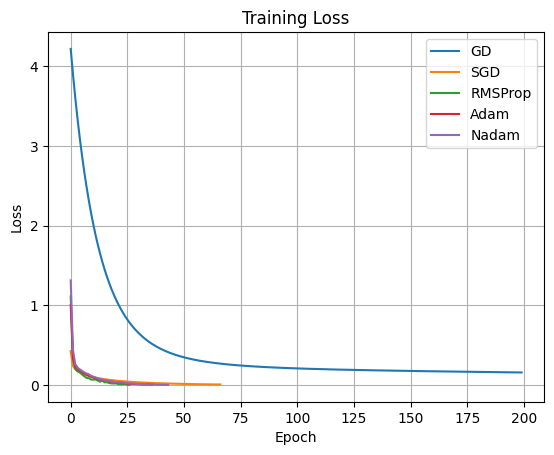

In [209]:
methods = {
    "GD": polynomial_regression_gradient_descent,
    "SGD": polynomial_regression_SGD,
    "RMSProp": polynomial_regression_rmsprop,
    "Adam": polynomial_regression_adam,
    "Nadam": polynomial_regression_nadam,
}

for name, method in methods.items():
    theta, losses, epochs = method(X_train, y_train, lr=0.01, n_iter=200)

    plt.plot(losses, label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

The optimal number of iterations of each method option

In [210]:
def evaluate_iterations(method, X_train, y_train, X_test, y_test, iterations, lr=0.01):

    results = []

    for n in iterations:
        theta, losses, epochs = method(
            X_train,
            y_train,
            lr=lr,
            n_iter=n
        )
        y_pred = X_test @ theta
        mse = mean_squared_error(y_test, y_pred)

        results.append({
            "iterations": n,
            "epochs_used": epochs,
            "final_loss": losses[-1],
            "test_mse": mse
        })

    return pd.DataFrame(results)

In [211]:
iterations = [10,50,100,200,500,1000]

gd_results = evaluate_iterations(
    polynomial_regression_gradient_descent,
    X_train,
    y_train,
    X_test,
    y_test,
    iterations
)

gd_results

,iterations,epochs_used,final_loss,test_mse
0,10,10,2.158584,2.141872
1,50,50,0.355295,0.394429
2,100,100,0.209372,0.255992
3,200,200,0.157658,0.190621
4,500,500,0.091304,0.108697
5,1000,662,0.071886,0.085118


In [212]:
sgd_results = evaluate_iterations(
    polynomial_regression_SGD,
    X_train,
    y_train,
    X_test,
    y_test,
    iterations
)
sgd_results

,iterations,epochs_used,final_loss,test_mse
0,10,10,0.105940,0.123933
1,50,50,0.014729,0.016532
2,100,72,0.005618,0.006394
3,200,84,0.003321,0.003906
4,500,67,0.006973,0.008056
5,1000,32,0.032988,0.039774


In [213]:
rmsprop_results = evaluate_iterations(
    polynomial_regression_rmsprop,
    X_train,
    y_train,
    X_test,
    y_test,
    iterations
)
rmsprop_results

,iterations,epochs_used,final_loss,test_mse
0,10,10,0.071365,0.085999
1,50,11,0.066021,0.072561
2,100,31,0.001952,0.002558
3,200,34,0.000324,0.000454
4,500,37,0.000075,0.000203
5,1000,35,0.000472,0.000389


In [214]:
adam_results = evaluate_iterations(
    polynomial_regression_adam,
    X_train,
    y_train,
    X_test,
    y_test,
    iterations
)
adam_results

,iterations,epochs_used,final_loss,test_mse
0,10,10,0.107068,0.129872
1,50,16,0.061105,0.071519
2,100,40,0.003109,0.003256
3,200,28,0.016103,0.020587
4,500,33,0.008612,0.011428
5,1000,21,0.035846,0.038158


In [215]:
nadam_results = evaluate_iterations(
    polynomial_regression_nadam,
    X_train,
    y_train,
    X_test,
    y_test,
    iterations
)
nadam_results

,iterations,epochs_used,final_loss,test_mse
0,10,10,0.112165,0.129723
1,50,47,0.000604,0.000693
2,100,45,0.000623,0.000777
3,200,21,0.033515,0.041360
4,500,47,0.000383,0.000297
5,1000,37,0.004324,0.003896


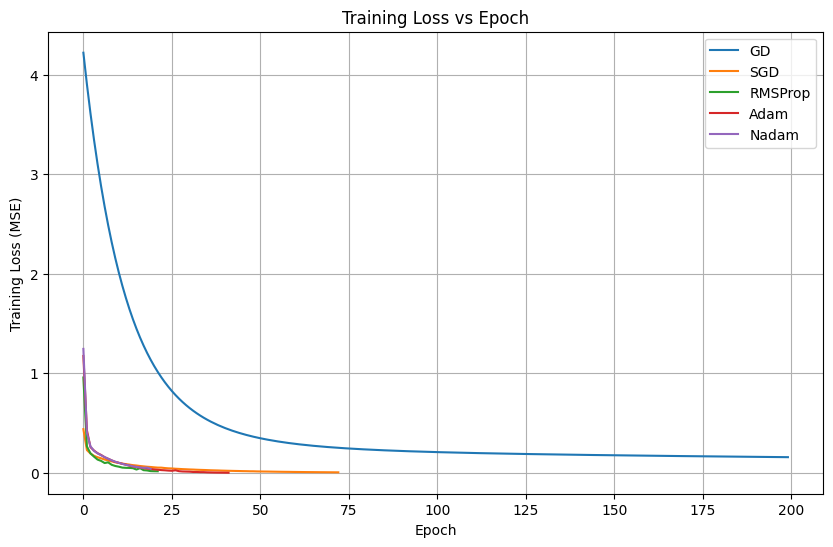

In [216]:
plt.figure(figsize=(10,6))

for name, method in methods.items():

    theta, losses, epochs = method(
        X_train,
        y_train,
        lr=0.01,
        n_iter=200
    )

    plt.plot(losses, label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss vs Epoch")

plt.legend()
plt.grid(True)

plt.show()

# Summary

All methods were evaluated under the same conditions, so the differences in performance are due to the characteristics of the optimization algorithms.

The graph illustrates how the MSE changes as the number of iterations increases.

All methods reduce the error over time, but their convergence rates differ. Gradient Descent (GD) converges the slowest and still has the highest MSE after 1000 iterations. SGD converges much faster, reaching a very small MSE after about 50–100 iterations. RMSProp, Adam, and Nadam converge the fastest, with almost no improvement after 50–100 iterations.

Therefore, 50–100 iterations can be considered sufficient for SGD, RMSProp, Adam, and Nadam on this dataset, while GD requires more than 1000 iterations to achieve similar convergence with the chosen learning rate.

The timing results also show that adaptive optimization methods achieve low error with fewer iterations, making them more computationally efficient than standard Gradient Descent.